# Appendix E — Recall guard experiment

This notebook displays validated results from the experiment pipeline. It does not
recalculate portfolio returns, drawdowns, performance statistics, or the experiment.

## The two switches

Think of each rebalance as a portfolio manager briefing an analyst.

- **PIT information** uses only what was available on that rebalance date. The
  prompt hides the date and asset names, so the historical episode is harder to
  recognize.
- **Identifying information** shows the real date, asset names, and raw macro
  readings. That can reveal the historical episode. It is a diagnostic, not a
  deployable input.
- **Guard on** reduces a raw portfolio tilt when the model appears likely to
  recognize past market history.
- **Guard off** leaves the raw tilt unchanged. Turning the guard off does not
  turn PIT information into identifying information.

Only **PIT information with the guard on** is deployable. The other three lines
are diagnostics. The split at **1 June 2024** was fixed in advance for reporting.
A difference before and after that date is descriptive, not proof of a recall or
contamination effect. No significant change and no visible change are valid results.


In [1]:
from __future__ import annotations

import hashlib
import json
import os
import struct
import sys
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

EXPECTED_BUNDLE_SCHEMA = "canonical_guard_ablation_reports.v1"
EXPECTED_SOURCE_RUN_SCHEMA = "factor_guard_ablation_run.v1"
EXPECTED_PRODUCER = "scripts/build_tear_sheet.py"
EXPECTED_TABLE_SCHEMAS = {
    "tear_sheet_factor_guard_ablation_ext2026.parquet": "tear_sheet.factor_guard_ablation.v1",
    "factor_guard_ablation_equity_ext2026.parquet": "factor_guard_ablation.equity.v1",
    "factor_guard_ablation_panel_ext2026.parquet": "factor_guard_ablation.panel.v1",
}
CONFIG_IDS = (
    "factor_pit_ext2026",
    "factor_pit_unguarded_diagnostic_ext2026",
    "factor_nonpit_diagnostic_ext2026",
    "factor_nonpit_unguarded_diagnostic_ext2026",
)
CUTOFF = pd.Timestamp("2024-06-01")
SURFACE = "#fcfcfb"
INK = "#0b0b0b"
SECONDARY = "#52514e"
GRID = "#e1e0d9"
ENTITY_COLORS = {
    "factor_pit_ext2026": "#2a78d6",
    "factor_pit_unguarded_diagnostic_ext2026": "#eb6834",
    "factor_nonpit_diagnostic_ext2026": "#1baf7a",
    "factor_nonpit_unguarded_diagnostic_ext2026": "#eda100",
}
ENTITY_STYLES = {
    "factor_pit_ext2026": ("-", "o"),
    "factor_pit_unguarded_diagnostic_ext2026": ("--", "s"),
    "factor_nonpit_diagnostic_ext2026": ("-.", "^"),
    "factor_nonpit_unguarded_diagnostic_ext2026": (":", "D"),
}
PRESENTATION_LABELS = {
    "factor_pit_ext2026": "PIT information, guard on (deployable)",
    "factor_pit_unguarded_diagnostic_ext2026": "PIT information, guard off (diagnostic)",
    "factor_nonpit_diagnostic_ext2026": "Identifying information, guard on (diagnostic)",
    "factor_nonpit_unguarded_diagnostic_ext2026": "Identifying information, guard off (combined diagnostic)",
}
PROTOCOL_INFORMATION = {
    "factor_pit_ext2026": "PIT, anonymized",
    "factor_pit_unguarded_diagnostic_ext2026": "PIT, anonymized",
    "factor_nonpit_diagnostic_ext2026": "Identifying date, assets, and macro readings",
    "factor_nonpit_unguarded_diagnostic_ext2026": "Identifying date, assets, and macro readings",
}
PROTOCOL_CHANGE = {
    "factor_pit_ext2026": "Deployable reference",
    "factor_pit_unguarded_diagnostic_ext2026": "Guard changes only",
    "factor_nonpit_diagnostic_ext2026": "Information shown changes",
    "factor_nonpit_unguarded_diagnostic_ext2026": "Information and guard both change",
}


def find_repo_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / ".git").exists():
            return candidate
    raise RuntimeError("Repository root not found; run this notebook inside the repository.")


IMPORT_REPO_ROOT = find_repo_root(Path.cwd())
if str(IMPORT_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(IMPORT_REPO_ROOT))
from macro_framework.appendix_presentation import markdown_lines


def resolve_repo_path(repo_root: Path, raw: str | Path, label: str) -> Path:
    candidate = Path(raw).expanduser()
    if not candidate.is_absolute():
        candidate = repo_root / candidate
    resolved = candidate.resolve()
    try:
        resolved.relative_to(repo_root)
    except ValueError as exc:
        raise ValueError(f"{label} must remain inside repository root {repo_root}: {resolved}") from exc
    return resolved


def repo_relative_path(repo_root: Path, path: Path, label: str) -> str:
    try:
        return path.resolve().relative_to(repo_root.resolve()).as_posix()
    except ValueError as exc:
        raise ValueError(f"{label} must remain inside repository root {repo_root}: {path}") from exc


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def completed_manifest_sha256(marker_path: Path) -> str:
    lines = marker_path.read_text(encoding="utf-8").splitlines()
    if len(lines) != 1 or not lines[0].startswith("manifest_sha256="):
        raise ValueError(f"{marker_path} must equal one manifest_sha256=<64 hex> line")
    value = lines[0].removeprefix("manifest_sha256=")
    if lines[0] != f"manifest_sha256={value}" or len(value) != 64 or any(ch not in "0123456789abcdef" for ch in value):
        raise ValueError(f"Malformed exact completed-marker manifest SHA in {marker_path}")
    return value


def require_column(frame: pd.DataFrame, candidates: tuple[str, ...], context: str) -> str:
    matches = [name for name in candidates if name in frame.columns]
    if not matches:
        raise ValueError(f"{context} requires one of columns {candidates}; observed={list(frame.columns)}")
    return matches[0]


def table_entry(manifest: dict, filename: str) -> tuple[str, dict]:
    inventory = manifest.get("tables")
    if not isinstance(inventory, dict):
        raise ValueError("Bundle manifest requires a tables inventory mapping")
    matches = [(name, meta) for name, meta in inventory.items() if isinstance(meta, dict) and Path(str(meta.get("file", ""))).name == filename]
    if len(matches) != 1:
        raise ValueError(f"Manifest must inventory {filename} exactly once; matches={len(matches)}")
    return matches[0]


def validate_frame_inventory(repo_root: Path, frame: pd.DataFrame, path: Path, meta: dict, context: str) -> dict:
    observed_sha = sha256_file(path)
    if observed_sha != meta.get("sha256"):
        raise ValueError(f"{context} hash mismatch: manifest={meta.get('sha256')} observed={observed_sha}")
    if int(meta.get("rows", -1)) != len(frame):
        raise ValueError(f"{context} row-count mismatch: manifest={meta.get('rows')} observed={len(frame)}")
    expected_schema = EXPECTED_TABLE_SCHEMAS[path.name]
    schema = meta.get("schema", meta.get("schema_id"))
    if schema != expected_schema:
        raise ValueError(f"{context} schema mismatch: expected {expected_schema}, observed {schema}")
    return {"file": repo_relative_path(repo_root, path, context), "sha256": observed_sha, "rows": len(frame), "schema": expected_schema}


def validate_source_child_run_lineage(repo_root: Path, source_run_dir: Path, bundle_manifest: dict) -> dict:
    source_declaration = bundle_manifest.get("input_manifests")
    if not isinstance(source_declaration, dict) or set(source_declaration) != {"factor_guard_ablation_run"}:
        raise ValueError("Canonical bundle must pin exactly factor_guard_ablation_run")
    pinned = source_declaration["factor_guard_ablation_run"]
    if not isinstance(pinned, dict):
        raise ValueError("factor_guard_ablation_run lineage declaration must be a mapping")
    manifest_path = source_run_dir / "manifest.json"
    marker_path = source_run_dir / "COMPLETED"
    if not manifest_path.is_file() or not marker_path.is_file():
        raise FileNotFoundError(f"Completed source guard-ablation run not found at {source_run_dir}")
    manifest_sha = sha256_file(manifest_path)
    if completed_manifest_sha256(marker_path) != manifest_sha:
        raise ValueError("Source child-run COMPLETED marker does not exactly bind manifest SHA")
    source_manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
    if source_manifest.get("schema") != EXPECTED_SOURCE_RUN_SCHEMA or source_manifest.get("completed") is not True:
        raise ValueError(f"Source child run must be completed {EXPECTED_SOURCE_RUN_SCHEMA}")
    if (source_manifest.get("run_id"), manifest_sha) != (pinned.get("run_id"), pinned.get("manifest_sha256")):
        raise ValueError("Canonical bundle lineage diverges from source child-run identity/hash")
    if not isinstance(source_manifest.get("source_commit"), str) or not source_manifest["source_commit"]:
        raise ValueError("Source child run must pin source_commit")
    parents = source_manifest.get("input_manifests")
    if not isinstance(parents, dict) or not {"factor_run", "market_snapshot"}.issubset(parents):
        raise ValueError("Source child run must pin parent Factor and market manifests")
    parent_specs = (("factor_run", "run_id"), ("market_snapshot", "snapshot_id"))
    for role, identity_field in parent_specs:
        declaration = parents[role]
        identity = declaration.get(identity_field) if isinstance(declaration, dict) else None
        parent_sha = declaration.get("manifest_sha256") if isinstance(declaration, dict) else None
        if not isinstance(identity, str) or not identity or not isinstance(parent_sha, str) or len(parent_sha) != 64:
            raise ValueError(f"Source child-run parent lineage is malformed for {role}")
    source_files = source_manifest.get("files")
    source_artifacts = bundle_manifest.get("source_artifacts")
    if not isinstance(source_files, dict) or not isinstance(source_artifacts, dict):
        raise ValueError("Canonical bundle and child run require source artifact inventories")
    if not {"metric_records", "panel"}.issubset(source_artifacts):
        raise ValueError("Canonical bundle must pin metric-record and panel source hashes")
    for role, declaration in source_artifacts.items():
        if not isinstance(declaration, dict):
            raise ValueError(f"Source artifact {role} is malformed")
        matches = [entry for entry in source_files.values() if isinstance(entry, dict) and entry.get("file") == declaration.get("file")]
        if len(matches) != 1 or matches[0].get("sha256") != declaration.get("sha256"):
            raise ValueError(f"Canonical source artifact lineage mismatch for {role}")
        source_path = (source_run_dir / str(declaration["file"])).resolve()
        try:
            source_path.relative_to(source_run_dir)
        except ValueError as exc:
            raise ValueError(f"Source artifact path escapes child run: {declaration['file']}") from exc
        if not source_path.is_file() or sha256_file(source_path) != declaration.get("sha256"):
            raise ValueError(f"Source artifact is missing or mutated for {role}")
    return {
        "run_id": source_manifest["run_id"],
        "manifest_path": repo_relative_path(repo_root, manifest_path, "source child-run manifest"),
        "manifest_sha256": manifest_sha,
        "schema": source_manifest["schema"],
        "source_commit": source_manifest["source_commit"],
        "parent_manifests": parents,
    }


def validate_table_semantics(frames: dict[str, pd.DataFrame]) -> None:
    tear = frames["tear_sheet_factor_guard_ablation_ext2026.parquet"]
    equity = frames["factor_guard_ablation_equity_ext2026.parquet"]
    panel = frames["factor_guard_ablation_panel_ext2026.parquet"]
    if len(tear) != 21 or list(tear.get("row_order", ())) != list(range(21)):
        raise ValueError("Guard-ablation tear sheet must preserve the exact 21-row canonical order")
    if set(tear.iloc[:12]["configuration"].astype(str)) != set(CONFIG_IDS):
        raise ValueError("Tear sheet reader rows must cover the exact four protocol cells")
    if tuple(equity.columns) != ("date", "configuration", "normalized_wealth", "drawdown", "relative_wealth", "relative_wealth_kind"):
        raise ValueError("Canonical equity table columns diverge")
    if set(equity["configuration"].astype(str)) != set(CONFIG_IDS):
        raise ValueError("Canonical equity table must cover the exact four protocol cells")
    if set(panel["configuration"].astype(str)) != set(CONFIG_IDS):
        raise ValueError("Canonical panel must cover the exact four protocol cells")
    expected_guard = {
        "factor_pit_ext2026": True,
        "factor_pit_unguarded_diagnostic_ext2026": False,
        "factor_nonpit_diagnostic_ext2026": True,
        "factor_nonpit_unguarded_diagnostic_ext2026": False,
    }
    for configuration, guarded in expected_guard.items():
        values = set(bool(value) for value in panel.loc[panel["configuration"].astype(str) == configuration, "guard_enabled"])
        if values != {guarded}:
            raise ValueError(f"Canonical panel guard flag mismatch for {configuration}")


def load_completed_bundle(repo_root: Path, bundle_dir: Path, source_run_dir: Path) -> tuple[dict, str, dict[str, pd.DataFrame], dict[str, dict], dict]:
    manifest_path = bundle_dir / "manifest.json"
    marker_path = bundle_dir / "COMPLETED"
    if not manifest_path.is_file() or not marker_path.is_file():
        raise FileNotFoundError(f"Completed guard-ablation bundle not found at {bundle_dir}")
    manifest_sha = sha256_file(manifest_path)
    if completed_manifest_sha256(marker_path) != manifest_sha:
        raise ValueError("Bundle COMPLETED marker does not exactly match manifest.json SHA-256")
    manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
    if manifest.get("schema") != EXPECTED_BUNDLE_SCHEMA or manifest.get("completed") is not True or manifest.get("producer") != EXPECTED_PRODUCER:
        raise ValueError(f"Expected completed {EXPECTED_BUNDLE_SCHEMA} from {EXPECTED_PRODUCER}")
    source_child_run = validate_source_child_run_lineage(repo_root, source_run_dir, manifest)
    frames: dict[str, pd.DataFrame] = {}
    source_inventory: dict[str, dict] = {}
    for filename in EXPECTED_TABLE_SCHEMAS:
        _, meta = table_entry(manifest, filename)
        relative = Path(str(meta["file"]))
        path = (bundle_dir / relative).resolve()
        try:
            path.relative_to(bundle_dir)
        except ValueError as exc:
            raise ValueError(f"Manifest table path escapes bundle: {relative}") from exc
        if not path.is_file():
            raise FileNotFoundError(path)
        frame = pd.read_parquet(path)
        source_inventory[filename] = validate_frame_inventory(repo_root, frame, path, meta, filename)
        frames[filename] = frame
    validate_table_semantics(frames)
    return manifest, manifest_sha, frames, source_inventory, source_child_run


def source_hash_snapshot(repo_root: Path, bundle_dir: Path, source_run_dir: Path, source_inventory: dict[str, dict], bundle_manifest: dict) -> dict[str, str]:
    snapshot = {
        "bundle/manifest.json": sha256_file(bundle_dir / "manifest.json"),
        "bundle/COMPLETED": sha256_file(bundle_dir / "COMPLETED"),
        "source_run/manifest.json": sha256_file(source_run_dir / "manifest.json"),
        "source_run/COMPLETED": sha256_file(source_run_dir / "COMPLETED"),
    }
    snapshot.update({f"table/{name}": sha256_file(repo_root / meta["file"]) for name, meta in source_inventory.items()})
    for role, declaration in bundle_manifest["source_artifacts"].items():
        snapshot[f"source_artifact/{role}"] = sha256_file(source_run_dir / declaration["file"])
    return snapshot


def assert_sources_unchanged(repo_root: Path, bundle_dir: Path, source_run_dir: Path, source_inventory: dict[str, dict], bundle_manifest: dict, before: dict[str, str]) -> None:
    after = source_hash_snapshot(repo_root, bundle_dir, source_run_dir, source_inventory, bundle_manifest)
    if after != before:
        raise RuntimeError("Canonical guard-ablation inputs changed during presentation rendering")


def png_dimensions(path: Path) -> tuple[int, int]:
    with path.open("rb") as handle:
        header = handle.read(24)
    if len(header) != 24 or header[:8] != b"\x89PNG\r\n\x1a\n":
        raise ValueError(f"Not a PNG: {path}")
    return struct.unpack(">II", header[16:24])


def render_table_png(frame: pd.DataFrame, path: Path, title: str, *, max_rows: int = 24, font_size: float = 7.0) -> None:
    shown = frame.head(max_rows).copy()
    shown = shown.apply(lambda column: column.map(lambda value: "" if pd.isna(value) else str(value)))
    height = max(3.2, 0.34 * (len(shown) + 3))
    fig, ax = plt.subplots(figsize=(16, height), constrained_layout=True)
    fig.patch.set_facecolor(SURFACE)
    ax.set_facecolor(SURFACE)
    ax.axis("off")
    ax.set_title(title, loc="left", fontsize=13, fontweight="semibold", color=INK, pad=12)
    table = ax.table(cellText=shown.values, colLabels=shown.columns, loc="center", cellLoc="left", colLoc="left")
    table.auto_set_font_size(False)
    table.set_fontsize(font_size)
    table.scale(1.0, 1.35)
    for (row, _), cell in table.get_celld().items():
        cell.set_edgecolor(GRID)
        cell.set_linewidth(0.5)
        cell.set_facecolor("#f0efec" if row == 0 else SURFACE)
        cell.get_text().set_color(INK if row == 0 else SECONDARY)
        if row == 0:
            cell.get_text().set_weight("semibold")
    fig.savefig(path, dpi=180, bbox_inches="tight", facecolor=SURFACE)
    plt.close(fig)


def build_output_inventory(output_dir: Path, figure_names: tuple[str, ...]) -> dict[str, dict]:
    inventory: dict[str, dict] = {}
    for name in figure_names:
        path = output_dir / name
        width, height = png_dimensions(path)
        inventory[name] = {
            "file": name,
            "sha256": sha256_file(path),
            "bytes": path.stat().st_size,
            "width_px": width,
            "height_px": height,
            "media_type": "image/png",
        }
    return inventory


def write_presentation_manifest(*, repo_root: Path, notebook_path: Path, output_dir: Path, schema: str, appendix_id: str, bundle_dir: Path, bundle_manifest: dict, bundle_manifest_sha: str, source_inventory: dict[str, dict], source_child_run: dict, figure_names: tuple[str, ...]) -> Path:
    payload = {
        "schema": schema,
        "appendix_id": appendix_id,
        "completed": True,
        "generated_at": datetime.now(timezone.utc).isoformat(),
        "notebook": {
            "file": repo_relative_path(repo_root, notebook_path, "notebook source"),
            "sha256": sha256_file(notebook_path),
        },
        "source_bundle": {
            "path": repo_relative_path(repo_root, bundle_dir, "source bundle"),
            "schema": bundle_manifest["schema"],
            "report_id": bundle_manifest.get("report_id"),
            "manifest_sha256": bundle_manifest_sha,
            "completed_marker_sha256": sha256_file(bundle_dir / "COMPLETED"),
        },
        "source_child_run": source_child_run,
        "source_artifacts": bundle_manifest["source_artifacts"],
        "source_tables": source_inventory,
        "outputs": build_output_inventory(output_dir, figure_names),
    }
    path = output_dir / "presentation_manifest.json"
    path.write_text(json.dumps(payload, indent=2, sort_keys=True, allow_nan=False) + "\n", encoding="utf-8")
    return path


REPO_ROOT = find_repo_root(Path.cwd())
NOTEBOOK_PATH = resolve_repo_path(
    REPO_ROOT,
    os.environ.get("APPENDIX_E_NOTEBOOK_PATH", "notebooks/appendix_e_factor_guard_ablation.ipynb"),
    "APPENDIX_E_NOTEBOOK_PATH",
)
BUNDLE_DIR = resolve_repo_path(
    REPO_ROOT,
    os.environ.get("GUARD_ABLATION_BUNDLE_DIR", "data/provisional_remediation/canonical_guard_ablation_reports_v2"),
    "GUARD_ABLATION_BUNDLE_DIR",
)
SOURCE_RUN_DIR = resolve_repo_path(
    REPO_ROOT,
    os.environ.get("GUARD_ABLATION_SOURCE_RUN_DIR", "data/provisional_remediation/factor_guard_ablation_runs/factor_guard_ablation_ext2026_2019-01-01_2026-06-30_v2"),
    "GUARD_ABLATION_SOURCE_RUN_DIR",
)
OUTPUT_DIR = resolve_repo_path(
    REPO_ROOT,
    os.environ.get("APPENDIX_E_OUTPUT_DIR", "reports/appendix_e_factor_guard_ablation"),
    "APPENDIX_E_OUTPUT_DIR",
)
if any(OUTPUT_DIR == source or OUTPUT_DIR.is_relative_to(source) or source.is_relative_to(OUTPUT_DIR) for source in (BUNDLE_DIR, SOURCE_RUN_DIR)):
    raise ValueError("Appendix E output namespace must be separate from canonical input bundle and source run")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 9,
    "axes.titlesize": 12,
    "axes.labelsize": 9,
    "axes.edgecolor": "#c3c2b7",
    "axes.linewidth": 0.8,
    "axes.facecolor": SURFACE,
    "figure.facecolor": SURFACE,
    "grid.color": GRID,
    "grid.linewidth": 0.6,
    "grid.linestyle": "-",
    "legend.frameon": False,
    "lines.linewidth": 2.0,
    "lines.solid_capstyle": "round",
})

In [2]:
bundle_manifest, bundle_manifest_sha, frames, source_inventory, source_child_run = load_completed_bundle(
    REPO_ROOT, BUNDLE_DIR, SOURCE_RUN_DIR
)
source_hashes_before = source_hash_snapshot(
    REPO_ROOT, BUNDLE_DIR, SOURCE_RUN_DIR, source_inventory, bundle_manifest
)
summary = frames["tear_sheet_factor_guard_ablation_ext2026.parquet"].copy()
equity = frames["factor_guard_ablation_equity_ext2026.parquet"].copy()
panel = frames["factor_guard_ablation_panel_ext2026.parquet"].copy()

source_audit = pd.DataFrame(source_inventory).T.reset_index(names="table")
display(Markdown(markdown_lines([
    f"**Source validation passed:** `{bundle_manifest.get('report_id', BUNDLE_DIR.name)}`",
    f"Manifest SHA-256: `{bundle_manifest_sha}`",
    f"Experiment run: `{source_child_run['run_id']}`",
])))
display(source_audit[["table", "schema", "rows", "sha256"]])


**Source validation passed:** `canonical_guard_ablation_reports_v2`  
Manifest SHA-256: `eb58ecbe7a1a2f99e92b7593263d7049bab9b0a6af59f6a4e2f1100455110d91`  
Experiment run: `factor_guard_ablation_ext2026_2019-01-01_2026-06-30_v2`

,table,schema,rows,sha256
0,tear_sheet_factor_guard_ablation_ext2026.parquet,tear_sheet.factor_guard_ablation.v1,21,12ef959b3a08fbb28eba0c207f8a066a2c6f68e62074ff...
1,factor_guard_ablation_equity_ext2026.parquet,factor_guard_ablation.equity.v1,12336,4766a0f06907d5cd81d61c845a3de3ba816c56d8dabb5b...
2,factor_guard_ablation_panel_ext2026.parquet,factor_guard_ablation.panel.v1,360,720572a16d6ede207a3fcf1d86aa2e34f005398d674f4e...


In [3]:
config_col = require_column(summary, ("configuration",), "guard-ablation tear sheet")
period_col = require_column(summary, ("window",), "guard-ablation tear sheet")
obs_col = require_column(summary, ("n_obs",), "guard-ablation tear sheet")
reader_rows = summary.loc[summary["record_kind"].astype(str) == "reader"].copy()
if len(reader_rows) != 12 or set(reader_rows[config_col].astype(str)) != set(CONFIG_IDS):
    raise ValueError("Producer tear sheet must contain exact full/pre/post reader rows for four protocol cells")
if set(reader_rows[period_col].astype(str)) != {"full", "pre_cutoff", "post_cutoff"}:
    raise ValueError("Producer tear sheet must contain full, pre_cutoff, and post_cutoff windows")
if "cutoff_date" in summary.columns:
    cutoff_values = set(pd.to_datetime(summary["cutoff_date"].dropna()).dt.normalize())
    if cutoff_values != {CUTOFF}:
        raise ValueError(f"Canonical cutoff_date must be exactly {CUTOFF.date()}")

panel_date_col = require_column(panel, ("rebalance_date", "date"), "guard-ablation panel")
panel_config_col = require_column(panel, ("configuration",), "guard-ablation panel")
prompt_mode_col = require_column(panel, ("prompt_mode",), "guard-ablation panel")
guard_col = require_column(panel, ("guard_enabled",), "guard-ablation panel")
panel[panel_date_col] = pd.to_datetime(panel[panel_date_col])
protocol_source = panel.sort_values([panel_config_col, panel_date_col]).drop_duplicates(panel_config_col).set_index(panel_config_col)
expected_guard = {
    "factor_pit_ext2026": True,
    "factor_pit_unguarded_diagnostic_ext2026": False,
    "factor_nonpit_diagnostic_ext2026": True,
    "factor_nonpit_unguarded_diagnostic_ext2026": False,
}
for config_id in CONFIG_IDS:
    observed_guard = bool(protocol_source.loc[config_id, guard_col])
    if observed_guard is not expected_guard[config_id]:
        raise ValueError(f"Guard-state mismatch for {config_id}")

protocol_table = pd.DataFrame({
    "config_id": CONFIG_IDS,
    "Information shown": [PROTOCOL_INFORMATION[config_id] for config_id in CONFIG_IDS],
    "Guard": ["On" if expected_guard[config_id] else "Off" for config_id in CONFIG_IDS],
    "What changes": [PROTOCOL_CHANGE[config_id] for config_id in CONFIG_IDS],
    "Use": ["Deployable" if config_id == "factor_pit_ext2026" else "Diagnostic" for config_id in CONFIG_IDS],
})
display(Markdown("## Four settings: information shown to the model and recall guard"))
display(Markdown(
    "PIT and the guard are separate switches. The second row changes only the guard. "
    "The fourth row changes both the information shown and the guard."
))
display(protocol_table.drop(columns="config_id"))


## Four settings: information shown to the model and recall guard

PIT and the guard are separate switches. The second row changes only the guard. The fourth row changes both the information shown and the guard.

,Information shown,Guard,What changes,Use
0,"PIT, anonymized",On,Deployable reference,Deployable
1,"PIT, anonymized",Off,Guard changes only,Diagnostic
2,"Identifying date, assets, and macro readings",On,Information shown changes,Diagnostic
3,"Identifying date, assets, and macro readings",Off,Information and guard both change,Diagnostic


### Reading this figure
The top panel starts every setting at 1.00. The lower panel shows the fall from each setting's prior peak. Lines are experiment settings, not four deployable strategies.

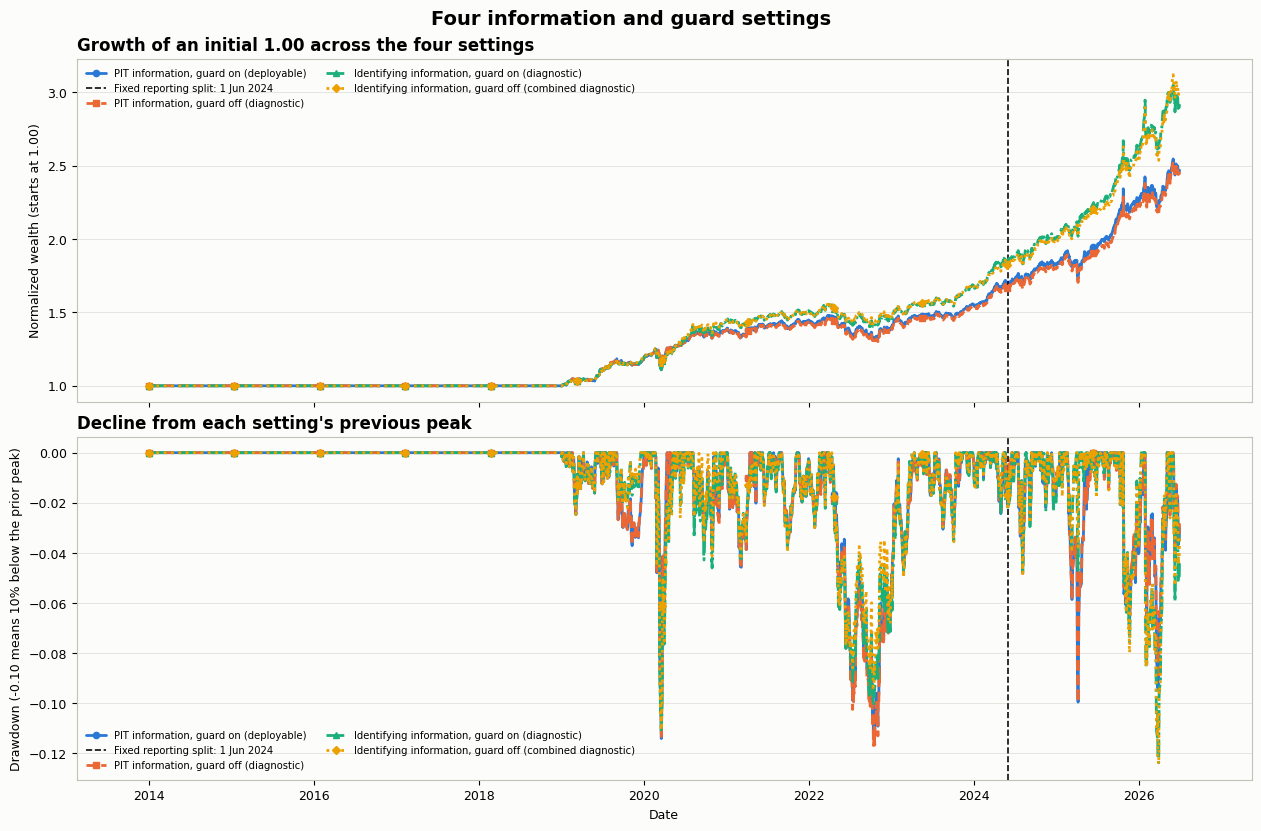

In [4]:
date_col = require_column(equity, ("date",), "guard-ablation equity table")
equity_config_col = require_column(equity, ("configuration",), "guard-ablation equity table")
equity_col = require_column(equity, ("normalized_wealth",), "guard-ablation equity table")
drawdown_col = require_column(equity, ("drawdown",), "guard-ablation equity table")
equity[date_col] = pd.to_datetime(equity[date_col])
if equity.duplicated([equity_config_col, date_col]).any():
    raise ValueError("Equity table requires one canonical row per configuration/date")

display(Markdown(
    "### Reading this figure\n"
    "The top panel starts every setting at 1.00. The lower panel shows the fall from each setting's prior peak. "
    "Lines are experiment settings, not four deployable strategies."
))
fig, axes = plt.subplots(2, 1, figsize=(12.5, 8.2), sharex=True, constrained_layout=True)
for config_id in CONFIG_IDS:
    rows = equity.loc[equity[equity_config_col].astype(str) == config_id].sort_values(date_col)
    linestyle, marker = ENTITY_STYLES[config_id]
    for ax, value_col in zip(axes, (equity_col, drawdown_col), strict=True):
        ax.plot(
            rows[date_col], rows[value_col], color=ENTITY_COLORS[config_id],
            linestyle=linestyle, marker=marker, markevery=max(1, len(rows) // 12),
            markersize=4.5, label=PRESENTATION_LABELS[config_id],
        )
        if config_id == CONFIG_IDS[0]:
            ax.axvline(CUTOFF, color=INK, linewidth=1.2, linestyle="--", label="Fixed reporting split: 1 Jun 2024")
        ax.grid(True, axis="y")
        ax.margins(x=0.07)
axes[0].set_title("Growth of an initial 1.00 across the four settings", loc="left", fontweight="semibold")
axes[0].set_ylabel("Normalized wealth (starts at 1.00)")
axes[1].set_title("Decline from each setting's previous peak", loc="left", fontweight="semibold")
axes[1].set_ylabel("Drawdown (-0.10 means 10% below the prior peak)")
axes[1].set_xlabel("Date")
axes[0].legend(loc="upper left", ncol=2, fontsize=7.2)
axes[1].legend(loc="lower left", ncol=2, fontsize=7.2)
fig.suptitle("Four information and guard settings", fontsize=14, fontweight="semibold")
fig.savefig(OUTPUT_DIR / "appendix_e_equity_drawdown.png", dpi=180, bbox_inches="tight", facecolor=SURFACE)
plt.show()


### Reading this figure
Above 1.00 means the numerator is ahead. Only the left panel isolates the guard because it keeps PIT information fixed.

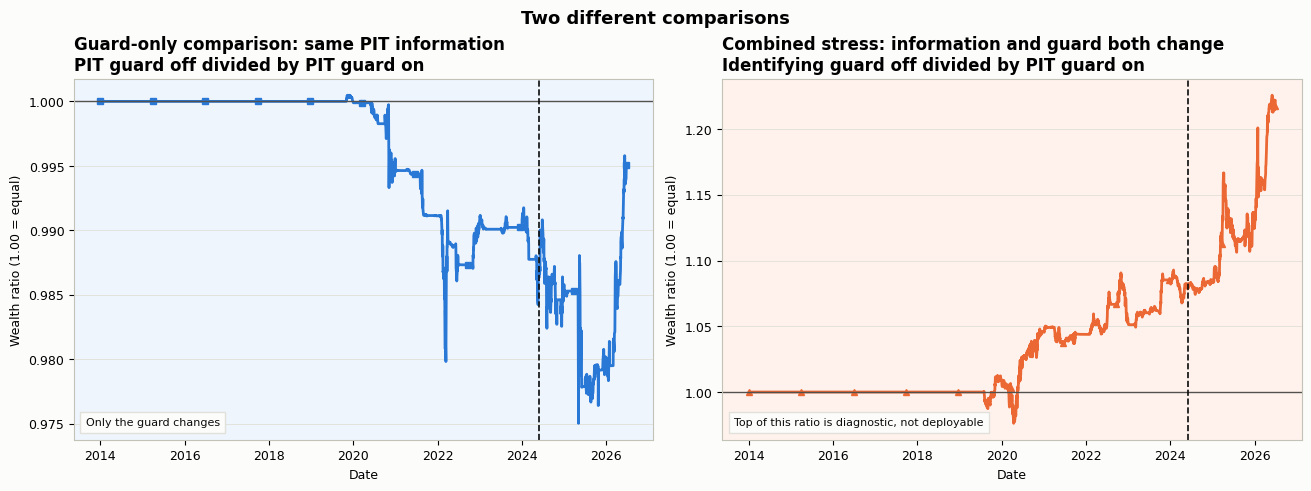

In [5]:
relative_kind_col = require_column(equity, ("relative_wealth_kind",), "guard-ablation equity table")
relative_col = require_column(equity, ("relative_wealth",), "guard-ablation equity table")

def canonical_relative_series(kind: str, context: str) -> pd.DataFrame:
    rows = equity.loc[equity[relative_kind_col].astype(str) == kind, [date_col, relative_col]].copy()
    if rows.empty or rows[relative_col].isna().any() or rows.duplicated(date_col).any():
        raise ValueError(f"{context} must be a complete unique producer-owned series")
    return rows.sort_values(date_col).rename(columns={relative_col: "relative_wealth"})

controlled = canonical_relative_series(
    "controlled_pit_unguarded_vs_guarded",
    "controlled PIT relative wealth",
)
combined = canonical_relative_series(
    "combined_nonpit_unguarded_vs_pit_guarded_stress",
    "combined naïve-stress relative wealth",
)

display(Markdown(
    "### Reading this figure\n"
    "Above 1.00 means the numerator is ahead. Only the left panel isolates the guard because it keeps PIT information fixed."
))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
relative_specs = (
    (axes[0], controlled, "Guard-only comparison: same PIT information", "PIT guard off divided by PIT guard on", "#2a78d6", "s", "#eef5fd", "Only the guard changes"),
    (axes[1], combined, "Combined stress: information and guard both change", "Identifying guard off divided by PIT guard on", "#eb6834", "^", "#fff2ed", "Top of this ratio is diagnostic, not deployable"),
)
for ax, data, title, subtitle, color, marker, wash, note in relative_specs:
    ax.set_facecolor(wash)
    ax.plot(data[date_col], data["relative_wealth"], color=color, marker=marker,
            markevery=max(1, len(data) // 10), markersize=5)
    ax.axhline(1.0, color=SECONDARY, linewidth=1.0)
    ax.axvline(CUTOFF, color=INK, linewidth=1.2, linestyle="--")
    ax.grid(True, axis="y")
    ax.set_title(f"{title}\n{subtitle}", loc="left", fontweight="semibold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Wealth ratio (1.00 = equal)")
    ax.text(0.02, 0.04, note, transform=ax.transAxes, fontsize=8, color=INK,
            bbox={"facecolor": SURFACE, "edgecolor": GRID, "pad": 4})
fig.suptitle("Two different comparisons", fontsize=13, fontweight="semibold")
fig.savefig(OUTPUT_DIR / "appendix_e_relative_wealth.png", dpi=180, bbox_inches="tight", facecolor=SURFACE)
plt.show()


In [6]:
inference_tokens = ("ssr_", "p_value", "alpha", "confidence", "significant", "effect", "interval", "bootstrap", "seed")
inference_columns = [name for name in reader_rows.columns if any(token in name.lower() for token in inference_tokens)]
if not inference_columns:
    raise ValueError("Producer tear sheet must supply canonical inference fields")
rebalance_col = next((name for name in ("rebalances", "n_rebalances") if name in reader_rows.columns), None)
if rebalance_col is None:
    rebalances = (
        panel.groupby(panel_config_col, sort=False)[panel_date_col]
        .nunique()
        .rename("rebalances")
        .reset_index()
        .rename(columns={panel_config_col: config_col})
    )
else:
    rebalances = None
metric_columns = list(dict.fromkeys([config_col, period_col, obs_col, *([rebalance_col] if rebalance_col else []), *inference_columns]))
canonical_metric_table = reader_rows[metric_columns].sort_values([config_col, period_col]).reset_index(drop=True)
if rebalances is not None:
    canonical_metric_table = canonical_metric_table.merge(rebalances, on=config_col, how="left", validate="many_to_one")

reader_metric_columns = [
    config_col, period_col, obs_col, "rebalances", "ssr_sr_full", "ssr_mean_rolling_sr",
    "ssr_ssr", "ssr_p_value", "ssr_p_value_lower",
]
missing_reader_metrics = [name for name in reader_metric_columns if name not in canonical_metric_table]
if missing_reader_metrics:
    raise ValueError(f"Producer tear sheet is missing reader metrics: {missing_reader_metrics}")
reader_metric_table = canonical_metric_table[reader_metric_columns].copy()
reader_setting_labels = {
    "factor_pit_ext2026": "PIT | guard on",
    "factor_pit_unguarded_diagnostic_ext2026": "PIT | guard off",
    "factor_nonpit_diagnostic_ext2026": "Identifying | guard on",
    "factor_nonpit_unguarded_diagnostic_ext2026": "Identifying | guard off",
}
reader_period_labels = {
    "full": "Full period",
    "pre_cutoff": "Before split",
    "post_cutoff": "After split",
}
reader_metric_table[config_col] = reader_metric_table[config_col].map(reader_setting_labels)
reader_metric_table[period_col] = reader_metric_table[period_col].map(reader_period_labels)
reader_metric_table = reader_metric_table.rename(columns={
    config_col: "Setting",
    period_col: "Period",
    obs_col: "Return observations",
    "rebalances": "Rebalances",
    "ssr_sr_full": "Sharpe",
    "ssr_mean_rolling_sr": "Average 1-year Sharpe",
    "ssr_ssr": "SSR effect size",
    "ssr_p_value": "P above benchmark",
    "ssr_p_value_lower": "P below benchmark",
})
for column in ("Sharpe", "Average 1-year Sharpe", "SSR effect size", "P above benchmark", "P below benchmark"):
    reader_metric_table[column] = reader_metric_table[column].map(lambda value: f"{float(value):.3f}")

display(Markdown("## Source-reported results before and after the fixed split"))
display(Markdown(
    "SSR is an effect size, not a test statistic. The bootstrap p-values provide the inference. "
    "The audit table below keeps the remaining reproducibility settings."
))
display(reader_metric_table)
audit_metric_table = canonical_metric_table.drop(columns=[name for name in reader_metric_columns if name in canonical_metric_table])
display(Markdown("### Audit settings"))
display(audit_metric_table)
render_table_png(
    reader_metric_table,
    OUTPUT_DIR / "appendix_e_protocol_metrics.png",
    "Appendix E: results before and after the fixed split",
    max_rows=24,
    font_size=7.4,
)


## Source-reported results before and after the fixed split

SSR is an effect size, not a test statistic. The bootstrap p-values provide the inference. The audit table below keeps the remaining reproducibility settings.

,Setting,Period,Return observations,Rebalances,Sharpe,Average 1-year Sharpe,SSR effect size,P above benchmark,P below benchmark
0,Identifying | guard on,Full period,1845,90,1.277,1.264,0.150,0.002,0.999
1,Identifying | guard on,After split,511,90,1.479,1.777,1.567,0.032,0.969
2,Identifying | guard on,Before split,1334,90,1.207,1.010,0.126,0.005,0.996
3,Identifying | guard off,Full period,1845,90,1.340,1.268,0.155,0.001,1.000
4,Identifying | guard off,After split,511,90,1.680,1.838,1.365,0.015,0.986
5,Identifying | guard off,Before split,1334,90,1.188,1.002,0.131,0.004,0.997
6,PIT | guard on,Full period,1845,90,1.091,1.017,0.133,0.002,0.999
7,PIT | guard on,After split,511,90,1.296,1.416,1.116,0.052,0.949
8,PIT | guard on,Before split,1334,90,1.004,0.800,0.109,0.011,0.990
9,PIT | guard off,Full period,1845,90,1.096,0.999,0.129,0.002,0.999


### Audit settings

,ssr_L_hac,ssr_alpha,ssr_block_len,ssr_n_boot,ssr_n_obs,ssr_n_rolling,ssr_periods_per_year,ssr_seed,ssr_sigma_hac,ssr_sr_star,ssr_window
0,137,0.05,1,1000,1845,1594,252,0,8.414946,0.0,252
1,44,0.05,1,1000,511,260,252,0,1.134421,0.0,252
2,120,0.05,1,1000,1334,1083,252,0,8.019167,0.0,252
3,137,0.05,1,1000,1845,1594,252,0,8.200113,0.0,252
4,52,0.05,1,1000,511,260,252,0,1.346166,0.0,252
5,120,0.05,1,1000,1334,1083,252,0,7.649003,0.0,252
6,137,0.05,1,1000,1845,1594,252,0,7.629619,0.0,252
7,50,0.05,1,1000,511,260,252,0,1.269297,0.0,252
8,120,0.05,1,1000,1334,1083,252,0,7.360578,0.0,252
9,137,0.05,1,1000,1845,1594,252,0,7.723196,0.0,252


### Reading this figure
This checks the saved guard rule, not portfolio performance. A recall probability of 0 keeps 100% of the raw tilt; a probability of 0.8 keeps 20%.

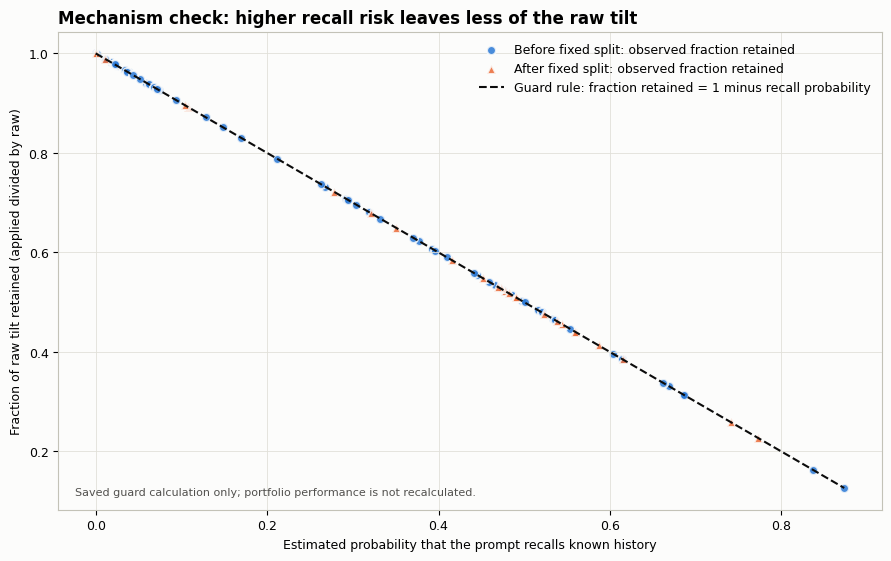

In [7]:
p_mem_col = require_column(panel, ("p_memorized",), "guard-ablation panel")
raw_tilt_col = require_column(panel, ("raw_view_tilt", "raw_tilt"), "guard-ablation panel")
applied_tilt_col = require_column(panel, ("applied_view_tilt", "applied_tilt"), "guard-ablation panel")
mechanism = panel.loc[panel[panel_config_col].astype(str) == "factor_pit_ext2026"].copy()
mechanism = mechanism.dropna(subset=[p_mem_col, raw_tilt_col, applied_tilt_col])
if mechanism.empty:
    raise ValueError("Guarded PIT panel has no persisted attenuation observations")
nonzero = mechanism[raw_tilt_col].astype(float).abs() > 1e-12
mechanism = mechanism.loc[nonzero].copy()
mechanism["persisted_observed_attenuation"] = mechanism[applied_tilt_col].astype(float) / mechanism[raw_tilt_col].astype(float)
mechanism["expected_attenuation"] = 1.0 - mechanism[p_mem_col].astype(float)
relation_error = (mechanism["persisted_observed_attenuation"] - mechanism["expected_attenuation"]).abs().max()
if relation_error > 1e-10:
    raise ValueError(f"Persisted raw/applied panel fields violate expected attenuation; max error={relation_error}")
mechanism["cutoff_segment"] = np.where(mechanism[panel_date_col] < CUTOFF, "Before fixed split", "After fixed split")
if set(mechanism["cutoff_segment"]) != {"Before fixed split", "After fixed split"}:
    raise ValueError("Mechanism panel requires both prespecified cutoff segments")

display(Markdown(
    "### Reading this figure\n"
    "This checks the saved guard rule, not portfolio performance. A recall probability of 0 keeps 100% of the raw tilt; "
    "a probability of 0.8 keeps 20%."
))
fig, ax = plt.subplots(figsize=(8.8, 5.5), constrained_layout=True)
for segment, color, marker in (("Before fixed split", "#2a78d6", "o"), ("After fixed split", "#eb6834", "^")):
    rows = mechanism.loc[mechanism["cutoff_segment"] == segment]
    ax.scatter(rows[p_mem_col], rows["persisted_observed_attenuation"], s=42, color=color, marker=marker,
               edgecolor=SURFACE, linewidth=1.5, alpha=0.85, label=f"{segment}: observed fraction retained")
expected_line = mechanism[[p_mem_col, "expected_attenuation"]].drop_duplicates().sort_values(p_mem_col)
ax.plot(expected_line[p_mem_col], expected_line["expected_attenuation"], color=INK, linestyle="--",
        linewidth=1.5, label="Guard rule: fraction retained = 1 minus recall probability")
ax.set_xlabel("Estimated probability that the prompt recalls known history")
ax.set_ylabel("Fraction of raw tilt retained (applied divided by raw)")
ax.set_title("Mechanism check: higher recall risk leaves less of the raw tilt", loc="left", fontweight="semibold")
ax.grid(True)
ax.legend(loc="best")
ax.text(0.02, 0.03, "Saved guard calculation only; portfolio performance is not recalculated.", transform=ax.transAxes,
        fontsize=8, color=SECONDARY)
fig.savefig(OUTPUT_DIR / "appendix_e_mechanism_attenuation.png", dpi=180, bbox_inches="tight", facecolor=SURFACE)
plt.show()


## Reading guide

- The split at 1 June 2024 was fixed before the results were read. A difference
  around it is descriptive, not proof of a causal recall effect.
- The tables report the producer's observations, rebalances, and inference. This
  notebook does not create substitute metrics.
- The left relative-wealth panel changes the guard while keeping PIT information
  fixed. The right panel changes both the information shown and the guard, so it
  is not a guard-only estimate.
- No significant change and no visible change are valid outcomes. The figures are
  not evidence filters.
- Only PIT information with the guard on is deployable. The other settings are
  diagnostic.


In [8]:
E_FIGURES = (
    "appendix_e_equity_drawdown.png",
    "appendix_e_relative_wealth.png",
    "appendix_e_protocol_metrics.png",
    "appendix_e_mechanism_attenuation.png",
)
assert_sources_unchanged(
    REPO_ROOT, BUNDLE_DIR, SOURCE_RUN_DIR, source_inventory, bundle_manifest, source_hashes_before
)
presentation_manifest_path = write_presentation_manifest(
    repo_root=REPO_ROOT,
    notebook_path=NOTEBOOK_PATH,
    output_dir=OUTPUT_DIR,
    schema="appendix_e_factor_guard_ablation.presentation.v1",
    appendix_id="appendix_e_factor_guard_ablation",
    bundle_dir=BUNDLE_DIR,
    bundle_manifest=bundle_manifest,
    bundle_manifest_sha=bundle_manifest_sha,
    source_inventory=source_inventory,
    source_child_run=source_child_run,
    figure_names=E_FIGURES,
)
assert_sources_unchanged(
    REPO_ROOT, BUNDLE_DIR, SOURCE_RUN_DIR, source_inventory, bundle_manifest, source_hashes_before
)
display(Markdown(markdown_lines([
    f"**Appendix E presentation manifest:** `{presentation_manifest_path}`",
    f"SHA-256: `{sha256_file(presentation_manifest_path)}`",
])))


**Appendix E presentation manifest:** `/home/mc/projects/Global_Macro_AI_Factors/reports/appendix_e_factor_guard_ablation/presentation_manifest.json`  
SHA-256: `64871075d537c22dbb7f4bc996248f93fe1196bc621022a9f9340509fa6f53a1`